# General-sentiment missingness explorer

Explores the missing-value situation of the **general sentiment** labels in the two
merged incremental outputs:

- `df_documents_general_merged.csv` — the raw zero-shot general-agreement output
  (`Agreement_General`, `Agreement_<Sector>`, `<Sector>_Sector`). One row per document.
- `df_fin_reg_core_merged.csv` — the analysis-ready core, where the general-agreement
  values arrive as `agreement_gpt` / `agreement_gpt_<Sector>` via a **LEFT join on `Print ISBN`**.

**Focus for now: the general-sentiment columns** — `Agreement_General` / `agreement_gpt`
and their per-sector siblings. (The fine-tuned `*_gpt_ft` columns are a separate
pipeline and are only touched briefly at the end for contrast.)

### Encoding cheat-sheet

| Column | Where | Meaning | Missing convention |
|---|---|---|---|
| `Agreement_General` | general file | whole-doc staff-vs-authorities agreement score, integer scale (roughly −5..+5; higher = more agreement) | never `99`; effectively never missing |
| `Agreement_<Sector>` | general file | per-sector agreement score; **`99` = insufficient sector info** in the raw model output | `99` is mapped to `NaN` downstream |
| `agreement_gpt` | core file | = `Agreement_General` joined on ISBN | `NaN` when the ISBN has **no general-agreement row** |
| `agreement_gpt_<Sector>` | core file | = `Agreement_<Sector>` joined on ISBN, with `99`→`NaN` | `NaN` = `99` (no sector info) **or** ISBN absent from general file |

The key structural fact this notebook surfaces: **the general file itself has 0 missing
`Agreement_*` values**, so any `NaN` in the core file's `agreement_gpt*` columns comes from
one of two mechanisms — a `99`→`NaN` remap (per-sector only) or an **ISBN that never got a
general-agreement row at all** (a coverage gap that leaks through the LEFT join).

In [20]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

DATA_DIR = Path(
    "/data/home/xiong/data/Fund/CSR/Tractions/output/incremental_update/06_07_2026_update"
)
GENERAL_PATH = DATA_DIR / "df_documents_general_merged.csv"
CORE_PATH = DATA_DIR / "df_fin_reg_core_merged.csv"


def norm_isbn(s: pd.Series) -> pd.Series:
    """Normalize Print ISBN so int/float/str variants compare equal (strip a trailing .0)."""
    return s.astype(str).str.replace(r"\.0$", "", regex=True)


gen = pd.read_csv(GENERAL_PATH)
core = pd.read_csv(CORE_PATH)
gen["isbn"] = norm_isbn(gen["Print ISBN"])
core["isbn"] = norm_isbn(core["Print ISBN"])

print(f"general: {gen.shape}")
print(f"core:    {core.shape}")
gen.head(2)

general: (1280, 22)
core:    (1281, 46)


,index,Print ISBN,staff,buff,country,year,publication_date,id,Agreement_General,Agreement_Monetary,Agreement_Fiscal,Agreement_External,Agreement_Financial,Agreement_Real,Agreement_Other,Monetary_Sector,Fiscal_Sector,External_Sector,Financial_Sector,Real_Sector,Other_Sector,isbn
0,0,9781513500676,1. Finland has suffered three years of recessi...,17. The authorities agreed with staff on the s...,Finland,2015.0,11/17/2015,0,2,99,1,2,2,2,2,[],"[{'area': 'pace of fiscal consolidation', 'sev...",[{'area': 'extent of current account/competiti...,[{'area': 'timing of systemic risk buffer legi...,[{'area': 'growth outlook and near-term downsi...,[{'area': 'extent and speed of wage bargaining...,9781513500676
1,1,9781513560069,"1. Spain’s recovery has gathered speed, but un...",9. The authorities have higher forecasts for m...,Spain,2015.0,08/14/2015,1,1,99,2,1,2,2,2,[],[{'area': 'strength of fiscal consolidation an...,[{'area': 'degree of external imbalances and R...,[{'area': 'need for additional banking sector ...,[{'area': 'pace of further reforms to lift lon...,[{'area': 'timing of additional labor market r...,9781513560069


## 1. Column inventory — which columns are the general-sentiment ones

In [21]:
SECTORS = ["Monetary", "Fiscal", "External", "Financial", "Real", "Other"]

# General file: raw zero-shot agreement scores
gen_agree_cols = ["Agreement_General"] + [f"Agreement_{s}" for s in SECTORS]
# Core file: the same values after join + 99->NaN remap
core_agree_cols = ["agreement_gpt"] + [f"agreement_gpt_{s}" for s in SECTORS]

print("General-file agreement columns:", gen_agree_cols)
print("Core-file  agreement columns:", core_agree_cols)

General-file agreement columns: ['Agreement_General', 'Agreement_Monetary', 'Agreement_Fiscal', 'Agreement_External', 'Agreement_Financial', 'Agreement_Real', 'Agreement_Other']
Core-file  agreement columns: ['agreement_gpt', 'agreement_gpt_Monetary', 'agreement_gpt_Fiscal', 'agreement_gpt_External', 'agreement_gpt_Financial', 'agreement_gpt_Real', 'agreement_gpt_Other']


Number of documents per year:
year
2015    115
2016    129
2017    133
2018    118
2019    135
2020     33
2021    122
2022    115
2023    109
2024    121
2025    134
2026     17
dtype: int64


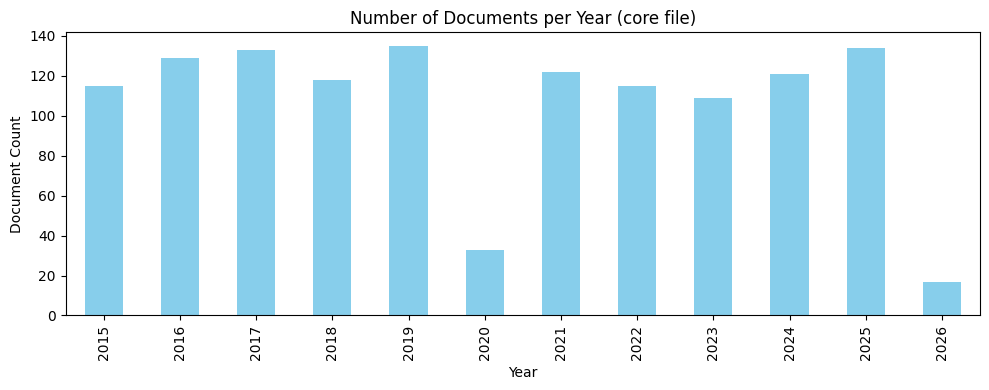

In [22]:
# Plot number of documents across years in the core file
doc_count_per_year = core.groupby("year").size().sort_index()
print("Number of documents per year:")
print(doc_count_per_year)

plt.figure(figsize=(10, 4))
doc_count_per_year.plot(kind="bar", color="skyblue")
plt.title("Number of Documents per Year (core file)")
plt.xlabel("Year")
plt.ylabel("Document Count")
plt.tight_layout()
plt.show()

## 2. Missingness overview — general file vs core file, side by side

The general file is the *source*; the core file is the *joined-in* copy. Comparing the two
columns immediately tells you whether missingness is created by the model (`99`) or by the join.

In [23]:
def missing_table(df, cols):
    rows = []
    for c in cols:
        n_missing = df[c].isna().sum()
        rows.append({
            "column": c,
            "n_rows": len(df),
            "n_missing": int(n_missing),
            "pct_missing": round(100 * n_missing / len(df), 1),
        })
    return pd.DataFrame(rows)


print("=== GENERAL file (raw source) ===")
display(missing_table(gen, gen_agree_cols))
print("=== CORE file (joined + 99->NaN) ===")
display(missing_table(core, core_agree_cols))

=== GENERAL file (raw source) ===


,column,n_rows,n_missing,pct_missing
0,Agreement_General,1280,0,0.0
1,Agreement_Monetary,1280,0,0.0
2,Agreement_Fiscal,1280,0,0.0
3,Agreement_External,1280,0,0.0
4,Agreement_Financial,1280,0,0.0
5,Agreement_Real,1280,0,0.0
6,Agreement_Other,1280,0,0.0


=== CORE file (joined + 99->NaN) ===


,column,n_rows,n_missing,pct_missing
0,agreement_gpt,1281,1,0.1
1,agreement_gpt_Monetary,1281,353,27.6
2,agreement_gpt_Fiscal,1281,4,0.3
3,agreement_gpt_External,1281,87,6.8
4,agreement_gpt_Financial,1281,14,1.1
5,agreement_gpt_Real,1281,13,1.0
6,agreement_gpt_Other,1281,14,1.1


Distribution of missing agreement_gpt over year:
year
2017    1
dtype: int64


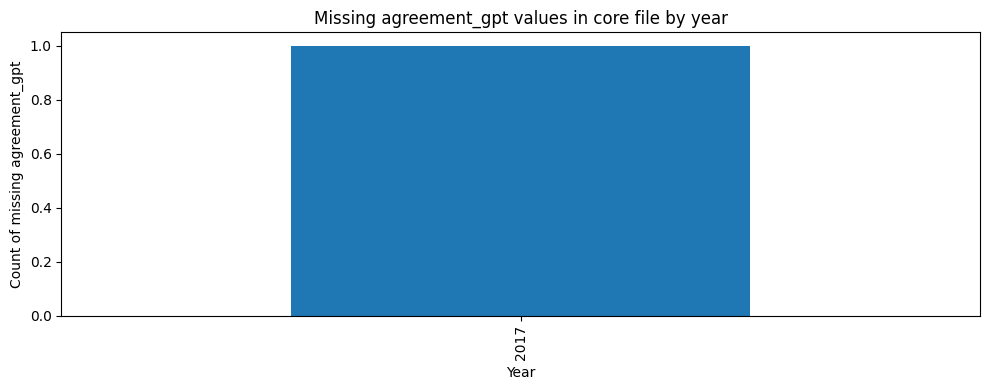

In [24]:
missing_per_year = core[core["agreement_gpt"].isna()].groupby("year").size().sort_index()
print("Distribution of missing agreement_gpt over year:")
print(missing_per_year)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
missing_per_year.plot(kind="bar")
plt.title("Missing agreement_gpt values in core file by year")
plt.xlabel("Year")
plt.ylabel("Count of missing agreement_gpt")
plt.tight_layout()
plt.show()

## 3. Coverage gap: which ISBNs are in core but missing from the general file?

`agreement_gpt` (general, whole-document) is *never* `99`, so if it is `NaN` in the core file
the only possible cause is that **the document has no row in the general file** — the LEFT join
produced a blank. This isolates the pure coverage gap.

In [25]:
gen_isbns = set(gen["isbn"])
core_isbns = set(core["isbn"])

in_core_not_gen = core_isbns - gen_isbns
in_gen_not_core = gen_isbns - core_isbns
print(f"ISBNs in core: {len(core_isbns)}")
print(f"ISBNs in general: {len(gen_isbns)}")
print(f"in core but NOT in general (=> agreement_gpt will be NaN): {len(in_core_not_gen)}")
print(f"in general but NOT in core: {len(in_gen_not_core)}")

# Sanity check: does that set exactly explain the missing agreement_gpt?
missing_general_score = core[core["agreement_gpt"].isna()]
print(
    f"\nrows with agreement_gpt NaN: {len(missing_general_score)}; "
    f"of those, ISBN absent from general file: "
    f"{(~missing_general_score['isbn'].isin(gen_isbns)).sum()}"
)

ISBNs in core: 1281
ISBNs in general: 1280
in core but NOT in general (=> agreement_gpt will be NaN): 1
in general but NOT in core: 0

rows with agreement_gpt NaN: 1; of those, ISBN absent from general file: 1


In [26]:
# Who are these coverage-gap documents? (country / year / code)
gap = core[core["isbn"].isin(in_core_not_gen)][
    ["isbn", "country", "Primary Country Code", "year"]
].sort_values(["year", "country"])
print(f"{len(gap)} coverage-gap documents\n")
print("By year:")
print(gap["year"].value_counts().sort_index())
print("\nAny with missing country/code? ",
      f"country NaN={gap['country'].isna().sum()}, code NaN={gap['Primary Country Code'].isna().sum()}")
gap

1 coverage-gap documents

By year:
year
2017    1
Name: count, dtype: int64

Any with missing country/code?  country NaN=0, code NaN=0


,isbn,country,Primary Country Code,year
1110,9781484305775,Central African Economic and Monetary Community,CEMAC,2017


## 4. Per-sector missingness: split `99` (no sector info) vs join gap

For each per-sector core column `agreement_gpt_<Sector>`, a `NaN` can be either:

1. **`99` in the source** — the model was run on the document but found insufficient
   information for that sector (the raw general file carries `99`, which is remapped to `NaN`), or
2. **Coverage gap** — the ISBN has no general-agreement row at all (same 38 docs as above).

This cell decomposes each sector's missing count into those two buckets by looking back at the
raw value in the general file.

In [27]:
# Build an ISBN -> raw Agreement_<Sector> lookup from the general file.
gen_by_isbn = gen.drop_duplicates("isbn", keep="last").set_index("isbn")

rows = []
for s in SECTORS:
    core_col = f"agreement_gpt_{s}"
    gen_col = f"Agreement_{s}"
    nan_mask = core[core_col].isna()
    isbns_nan = core.loc[nan_mask, "isbn"]

    # bucket 1: ISBN absent from general file (coverage gap)
    gap_mask = ~isbns_nan.isin(gen_by_isbn.index)
    n_gap = int(gap_mask.sum())

    # bucket 2: ISBN present, raw value == 99 (insufficient sector info)
    present = isbns_nan[~gap_mask]
    raw_vals = gen_by_isbn.loc[present, gen_col]
    n_99 = int((raw_vals == 99).sum())
    n_other = int(len(present) - n_99)  # present, not 99, yet NaN in core (unexpected)

    rows.append({
        "sector": s,
        "core_missing": int(nan_mask.sum()),
        "= from_99 (no sector info)": n_99,
        "+ from_coverage_gap": n_gap,
        "+ unexplained": n_other,
    })

sector_breakdown = pd.DataFrame(rows)
sector_breakdown

,sector,core_missing,= from_99 (no sector info),+ from_coverage_gap,+ unexplained
0,Monetary,353,352,1,0
1,Fiscal,4,3,1,0
2,External,87,86,1,0
3,Financial,14,13,1,0
4,Real,13,12,1,0
5,Other,14,13,1,0


**Reading the table above:** for each sector, `core_missing` should equal
`from_99 + from_coverage_gap + unexplained`. `unexplained` should be 0 — if it is not, the
general file carries a non-99 value that still landed as `NaN` in core, which would point to a
join / dtype bug worth chasing. `from_99` is *expected / legitimate* (the document genuinely had
no discussion of that sector); `from_coverage_gap` is the same 38-doc gap as the whole-document case.

## 5. Distribution of the general-agreement score (non-missing)

A quick look at the actual score distribution, so "missing" is seen against the backdrop of what
a present value looks like. `Agreement_General` is the cleanest column (per-doc, never 99).

In [28]:
print("Agreement_General (general file) value counts:")
print(gen["Agreement_General"].value_counts(dropna=False).sort_index())

print("\nPer-sector raw Agreement_<Sector> — how often is the raw value 99?")
for s in SECTORS:
    col = f"Agreement_{s}"
    vc = gen[col].value_counts(dropna=False)
    n99 = int((gen[col] == 99).sum())
    print(f"  {col:20s}  99-count={n99:4d}  NaN-count={int(gen[col].isna().sum()):4d}")

Agreement_General (general file) value counts:
Agreement_General
-4      1
-3      3
-2      3
-1      6
 0      9
 1    175
 2    681
 3    244
 4    158
Name: count, dtype: int64

Per-sector raw Agreement_<Sector> — how often is the raw value 99?
  Agreement_Monetary    99-count= 352  NaN-count=   0
  Agreement_Fiscal      99-count=   3  NaN-count=   0
  Agreement_External    99-count=  86  NaN-count=   0
  Agreement_Financial   99-count=  13  NaN-count=   0
  Agreement_Real        99-count=  12  NaN-count=   0
  Agreement_Other       99-count=  13  NaN-count=   0


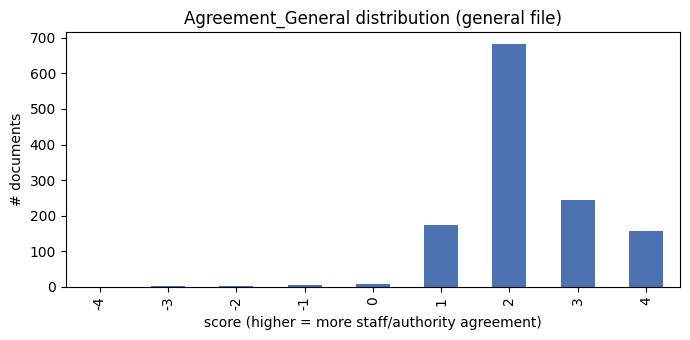

In [29]:
# Optional: a compact bar chart of the general score distribution.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3.5))
gen["Agreement_General"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#4c72b0")
ax.set_title("Agreement_General distribution (general file)")
ax.set_xlabel("score (higher = more staff/authority agreement)")
ax.set_ylabel("# documents")
plt.tight_layout()
plt.show()

## 6. Inspect the coverage-gap documents in the general file (should be empty)

Confirm the gap really is *absence*, not a present-but-blank row. If these ISBNs truly have no
general-agreement row, the filter below returns 0 rows.

In [30]:
present_gap_rows = gen[gen["isbn"].isin(in_core_not_gen)]
print(f"general-file rows for the {len(in_core_not_gen)} gap ISBNs: {len(present_gap_rows)}")
present_gap_rows[gen_agree_cols] if len(present_gap_rows) else "(none — confirmed pure absence)"

general-file rows for the 1 gap ISBNs: 0


'(none — confirmed pure absence)'

## 7. Contrast: fine-tuned general agreement (brief)

The core file also carries a fine-tuned overall-agreement column `agreement_gpt_ft` (boolean) and
`mon_agreement_general_gpt_ft` / `fis_agreement_general_gpt_ft`. These come from a *different*
(fine-tuned, per-sector) pipeline and have their own missingness. Shown here only so the two
families aren't conflated — the focus of this notebook is the zero-shot `agreement_gpt*` family above.

In [31]:
ft_cols = [c for c in [
    "agreement_gpt_ft",
    "mon_agreement_general_gpt_ft",
    "fis_agreement_general_gpt_ft",
] if c in core.columns]
display(missing_table(core, ft_cols))
for c in ft_cols:
    print(f"\n{c}:")
    print(core[c].value_counts(dropna=False).head())

,column,n_rows,n_missing,pct_missing
0,agreement_gpt_ft,1281,0,0.0
1,mon_agreement_general_gpt_ft,1281,277,21.6
2,fis_agreement_general_gpt_ft,1281,19,1.5



agreement_gpt_ft:
agreement_gpt_ft
False    756
True     525
Name: count, dtype: int64

mon_agreement_general_gpt_ft:
mon_agreement_general_gpt_ft
1.0    778
NaN    277
0.0    226
Name: count, dtype: int64

fis_agreement_general_gpt_ft:
fis_agreement_general_gpt_ft
0.0    651
1.0    611
NaN     19
Name: count, dtype: int64


## Takeaways

- The **general file** (`df_documents_general_merged.csv`) has **0 missing** `Agreement_*` values —
  the raw zero-shot output is complete for every document it covers.
- All missingness in the core `agreement_gpt*` columns comes from exactly two mechanisms:
  1. **`99` → `NaN`** (per-sector only): the model ran but found insufficient information for that
     sector. *Expected / legitimate.*
  2. **Coverage gap**: ~38 documents (mostly 2024 reports) are in the core file but have **no row
     in the general file**, so the LEFT join leaves every `agreement_gpt*` column `NaN` for them.
     These are ordinary countries with valid codes — i.e. a genuine *inference-coverage* gap in the
     general-agreement step, not the `irrelevant`/`99` design behaviour.
- `agreement_gpt` (whole-document) is never `99`, so its NaN count is a clean measure of the pure
  coverage gap; the per-sector columns add `99`s on top (see section 4's decomposition).

**If the goal is to close the gap:** re-run the general-agreement step (step 06 zero-shot general)
for the coverage-gap ISBNs listed in section 3, then re-merge — that populates their `agreement_gpt*`
values without touching the legitimate `99`→`NaN` cells.